# Draft tests

The idea with this script is to test final details of the network before writing a final notebook with the plots and instructions to replicate information in the document. 

In [1]:
# Libraries ------------------------

import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mesa

# Set a seed
np.random.seed(666)

# Plotting settings
from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': '#f97743',
    'Neutral': '#2f6edd',
    'Pro - environment': '#28b36a'
}

# Models ------------------------
from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel

My fear is that networks are not sufficiently large to reflect the particularities of $\alpha$

In [2]:
# Test clustering loss in the model: Batch run with small alphas in a large network
params = {"seed": 666, 
          "alpha": np.linspace(0.001, 1, 10),
          'N':[500],
          "gamma": [0.1], 
          "create_network": "watts_strogatz", 
          "k": [40], 
          "p": [1/1000],
          "rho": 1/3, 
          "one_active_agent_id": [2], 
          "seed_consumption": True, 
          "memory": [5,10,20]}

results_batch = mesa.batch_run(
    OneActiveStatusGameModel,
    parameters=params,
    iterations=1,
    max_steps=90,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

  0%|          | 0/30 [00:00<?, ?it/s]

In [3]:
results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_draft.csv")

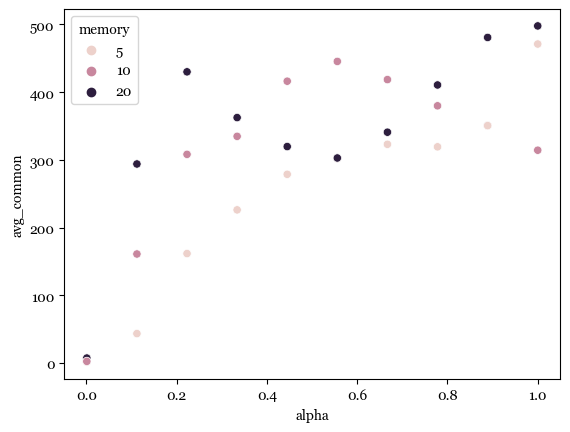

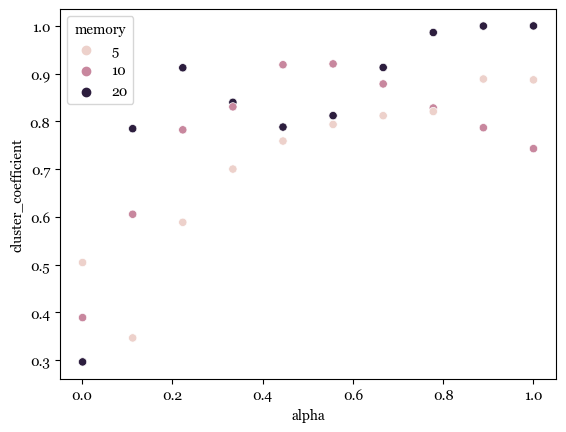

In [4]:
# Understand results
results_batch_df

# First, take a look at clustering
agent2 = results_batch_df.loc[results_batch_df["AgentID"] == 2]
sns.scatterplot(data=agent2, x="alpha", y="avg_common", hue="memory")
plt.show()
sns.scatterplot(data=agent2, x="alpha", y="cluster_coefficient", hue="memory")
plt.show()

In [ ]:
# Runs to build timelines for multiple alphas --------
runs_multi_alpha = {}

for alpha in np.linspace(0.001, 1, 10):
    one_agent_alpha = OneActiveStatusGameModel(N=350, one_active_agent_id=2, seed=666, lambda_s=1, memory=10,
        create_network="watts_strogatz", p=1/1000, gamma=1, k=10, rho=1/3, seed_consumption=True, alpha=alpha)
    
    for _ in range(100):
        one_agent_alpha.step()

    print(f"alpha = {alpha}")
    runs_multi_alpha[alpha] = one_agent_alpha.datacollector.get_model_vars_dataframe().reset_index()


fig, ax = plt.subplots()
for r in range(0,10):
    run = list(runs_multi_alpha.keys())[r]
    sns.lineplot(data=runs_multi_alpha[run].loc[runs_multi_alpha[run].index > 0], x="index", y="cluster_coefficient", label = f"alpha = {run}", ax = ax, linewidth = 1.3)

alpha = 0.001
alpha = 0.112
alpha = 0.223
alpha = 0.334
alpha = 0.445
alpha = 0.556
alpha = 0.667
alpha = 0.778
alpha = 0.889
alpha = 1.0


In [ ]:
# Run test with many agents ------
runs_multi_alpha_all = {}

for alpha in np.linspace(0.001, 1, 5):
    all_agents_alpha = statusgame_model(N=10000, seed=666, lambda_s=1, memory=5,
        create_network="watts_strogatz", p=1/1000, gamma=1, k=5, rho=1/3, seed_consumption=False, alpha=alpha)
    
    for _ in range(45):
        all_agents_alpha.step()

    print(f"alpha = {alpha}")
    runs_multi_alpha_all[alpha] = all_agents_alpha.datacollector.get_model_vars_dataframe().reset_index()


In [ ]:
fig, ax = plt.subplots()
for r in range(0,5):
    run = list(runs_multi_alpha_all.keys())[r]
    sns.lineplot(data=runs_multi_alpha_all[run].loc[runs_multi_alpha_all[run].index > 0], x="index", y="cluster_coefficient", label = f"alpha = {run}", ax = ax, linewidth = 1.3)


In [14]:
check_data =runs_multi_alpha[1]

In [15]:
check_data

,index,dense_degree,connected_components,max_path_length,cluster_coefficient
0,0,10.000000,1,35,0.665146
1,1,31.131429,1,3,0.350131
2,2,86.668571,1,2,0.339478
3,3,200.331429,1,2,0.589099
4,4,322.982857,1,2,0.922141
...,...,...,...,...,...
96,96,350.954286,1,2,0.999869
97,97,350.954286,1,2,0.999869
98,98,350.948571,1,2,0.999853
99,99,330.377143,1,2,0.941027


In [16]:
one_agent_alpha_single = OneActiveStatusGameModel(N=100, one_active_agent_id=2, seed=666, lambda_s=1, memory=10,
        create_network="watts_strogatz", p=1/1000, gamma=1, k=10, rho=1/3, seed_consumption=True, alpha=1)
    
for _ in range(100):
    if _ % 25 == 0:
        print(_)
    one_agent_alpha_single.step()

cluster_single = one_agent_alpha_single.datacollector.get_model_vars_dataframe().reset_index()

0
25
50
75


<Axes: xlabel='index', ylabel='cluster_coefficient'>

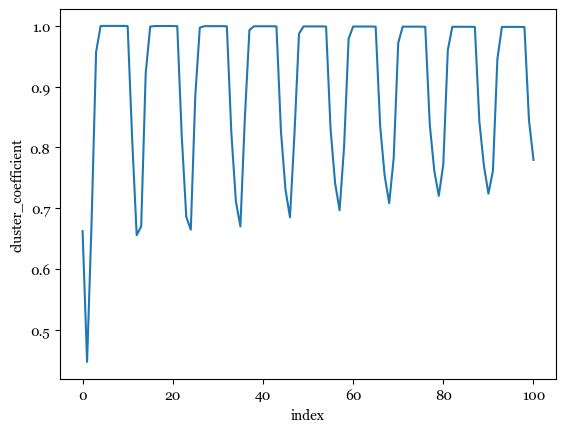

In [17]:
sns.lineplot(data = cluster_single, x="index", y="cluster_coefficient")

In [18]:
cluster_single.sort_values(by="cluster_coefficient")

,index,dense_degree,connected_components,max_path_length,cluster_coefficient
1,1,29.16,1,3,0.446860
12,12,64.26,1,2,0.655563
0,0,10.00,1,10,0.662066
24,24,66.02,1,2,0.664478
35,35,67.14,1,2,0.669811
...,...,...,...,...,...
7,7,101.00,1,1,1.000000
5,5,101.00,1,1,1.000000
8,8,101.00,1,1,1.000000
6,6,101.00,1,1,1.000000
